Dataset Shape: (20, 2)
   Study_Hours  Exam_Score
0          1.5          45
1          2.0          50
2          3.0          55
3          4.5          65
4          5.0          70


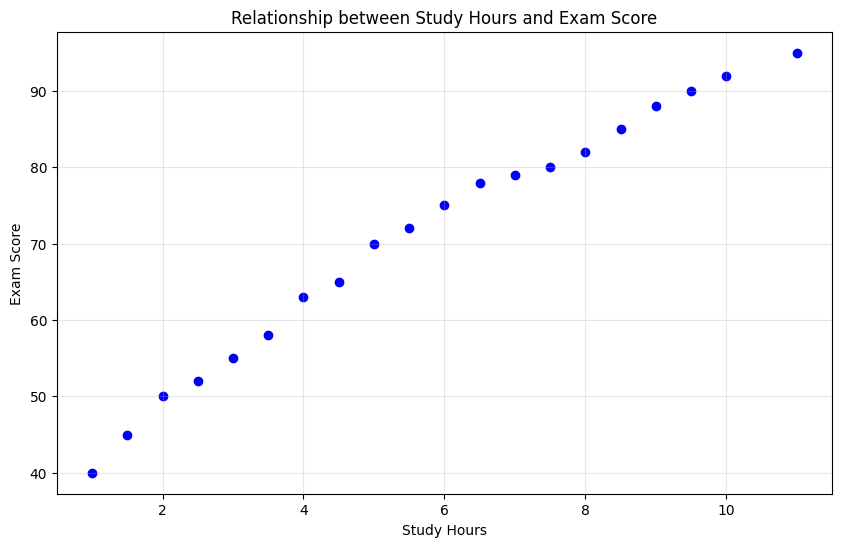


=== Model Parameters ===
Slope (m)     : 5.4348
Intercept (c) : 39.3137
R² Score      : 0.9806 (98.06%)

=== Model Performance ===
Mean Squared Error (MSE) : 5.0129
Root Mean Squared Error  : 2.2389
Mean Absolute Error (MAE): 1.7562


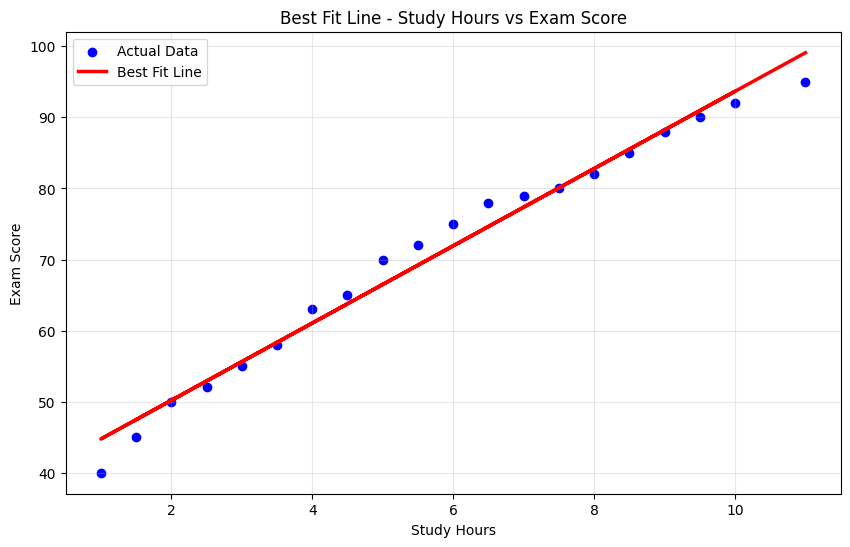


=== Interpretation ===
For every 1 additional hour of study, the student's Exam Score increases by approximately 5.43 marks on average.
The R² score of 0.9806 means 98.06% of the variation in Exam Scores can be explained by Study Hours.


In [34]:
# =============================================================================
#   STUDENT EXAM SCORE PREDICTION - SIMPLE LINEAR REGRESSION
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -------------------------- 1. Load Dataset --------------------------
data = {
    'Study_Hours': [1.5, 2.0, 3.0, 4.5, 5.0, 6.0, 7.5, 8.0, 9.0, 10.0,
                    1.0, 2.5, 3.5, 4.0, 5.5, 6.5, 7.0, 8.5, 9.5, 11.0],
    'Exam_Score': [45, 50, 55, 65, 70, 75, 80, 82, 88, 92,
                   40, 52, 58, 63, 72, 78, 79, 85, 90, 95]
}

df = pd.DataFrame(data)

print("Dataset Shape:", df.shape)
print(df.head())

# -------------------------- 2. Data Visualization --------------------------
plt.figure(figsize=(10, 6))
plt.scatter(df['Study_Hours'], df['Exam_Score'], color='blue')
plt.title('Relationship between Study Hours and Exam Score')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------- 3. Model Training --------------------------
X = df[['Study_Hours']]        # Feature (2D array)
y = df['Exam_Score']           # Target

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_
r2 = model.score(X, y)

print("\n=== Model Parameters ===")
print(f"Slope (m)     : {slope:.4f}")
print(f"Intercept (c) : {intercept:.4f}")
print(f"R² Score      : {r2:.4f} ({r2*100:.2f}%)")

# -------------------------- 4. Predictions & Evaluation --------------------------
y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)

print("\n=== Model Performance ===")
print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"Root Mean Squared Error  : {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# -------------------------- 5. Final Visualization --------------------------
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='red', linewidth=2.5, label='Best Fit Line')
plt.title('Best Fit Line - Study Hours vs Exam Score')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------- 6. Interpretation --------------------------
print("\n=== Interpretation ===")
print(f"For every 1 additional hour of study, the student's Exam Score increases by approximately {slope:.2f} marks on average.")
print(f"The R² score of {r2:.4f} means {r2*100:.2f}% of the variation in Exam Scores can be explained by Study Hours.")